# A Risk-Driven Framework for Predictive Maintenance of Distribution Transformers
## WITHOUT Burn Rate & Criticality

**IEOM Bangkok 2026 — Ablation Study**

---

This notebook implements the same predictive maintenance pipeline as the full-feature version,
but with **Burn Rate** and **Criticality** deliberately **excluded** from the feature set.

**Purpose:** Evaluate how well the models perform using only physical and operational
data — without expert-derived historical features. This answers: *"Can we predict
transformer failures for new installations or regions with no failure history?"*

**Key differences from the full-feature pipeline:**
1. `Burning rate [Failures/year]` — DROPPED
2. `Criticality according to previous study for ceramics level` — DROPPED
3. `burn_x_power` and `burn_x_eens` (engineered from Burn Rate) — DROPPED
4. Total features: **19** (vs 23 in the full pipeline)

Outputs go to: `outputs_no_burn/`

---
## Section 0: Configuration & Imports

In [1]:
# ============================================================================
# Section 0: Configuration & Imports
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, train_test_split
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, f1_score, fbeta_score,
    precision_score, recall_score, accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap

import warnings
warnings.filterwarnings('ignore')

# ── Global configuration ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# Paths
DATA_DIR = Path(r"E:\Projects_\predictive_analysis\ifti_vai\Transformer")
OUTPUT_DIR = Path(r"E:\Projects_\predictive_analysis\outputs_no_burn")
OUTPUT_DIR.mkdir(exist_ok=True)

PATH_2019 = DATA_DIR / "Dataset_Year_2019.xlsx"
PATH_2020 = DATA_DIR / "Dataset_Year_2020.xlsx"

# Column names (exact strings from the Excel files)
TARGET_2019 = "Burned transformers 2019"
TARGET_2020 = "Burned transformers 2020"
EENS_COL    = "Electric power not supplied EENS [kWh] "   # trailing space in file
USERS_COL   = "Number of users"
KM_COL      = "km of network LT:"
AVG_DDT     = "Average earth discharge density DDT [Rays/km^2-a\u00f1o]"
MAX_DDT     = "Maximum ground discharge density DDT [Rays/km^2-a\u00f1o]"
POWER_COL   = "POWER"
BURN_RATE   = "Burning rate  [Failures/year]"
CRITICALITY = "Criticality according to previous study for ceramics level"

# Known categorical columns
KNOWN_CATS = {
    "LOCATION", "SELF-PROTECTION", "Removable connectors",
    "Type of clients", "Type of installation", "Air network", "Circuit Queue",
}

# Publication figure settings
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_style("whitegrid")

print("Configuration loaded.")
print(f"Output directory: {OUTPUT_DIR}")

Configuration loaded.
Output directory: E:\Projects_\predictive_analysis\outputs_no_burn


e:\Projects_\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Section 1: Data Loading & Validation

**Paper Table 1**: Dataset summary statistics.

In [2]:
# ============================================================================
# Section 1: Data Loading & Validation
# ============================================================================
df_2019 = pd.read_excel(PATH_2019)
df_2020 = pd.read_excel(PATH_2020)

# Verify dimensions
print(f"2019: {df_2019.shape[0]:,} rows x {df_2019.shape[1]} columns")
print(f"2020: {df_2020.shape[0]:,} rows x {df_2020.shape[1]} columns")

# Verify column alignment (except target)
feat_cols_19 = sorted([c for c in df_2019.columns if c != TARGET_2019])
feat_cols_20 = sorted([c for c in df_2020.columns if c != TARGET_2020])
assert feat_cols_19 == feat_cols_20, "Feature columns mismatch!"
print("Column alignment: OK")

# Class distributions
n_pos_19 = int(df_2019[TARGET_2019].sum())
n_pos_20 = int(df_2020[TARGET_2020].sum())
print(f"\n2019 failures: {n_pos_19:,} / {len(df_2019):,} ({n_pos_19/len(df_2019)*100:.2f}%)")
print(f"2020 failures: {n_pos_20:,} / {len(df_2020):,} ({n_pos_20/len(df_2020)*100:.2f}%)")

# Missing values
print(f"\nMissing values 2019: {df_2019.isnull().sum().sum()}")
print(f"Missing values 2020: {df_2020.isnull().sum().sum()}")

# Paper Table 1: Dataset Summary
print("\n" + "="*60)
print("TABLE 1: Dataset Summary")
print("="*60)
table1_data = {
    'Attribute': ['Total transformers', 'Burned (positive class)',
                  'Not burned (negative class)', 'Failure rate (%)',
                  'Number of features'],
    '2019 (Train)': [f"{len(df_2019):,}", f"{n_pos_19:,}",
                     f"{len(df_2019)-n_pos_19:,}", f"{n_pos_19/len(df_2019)*100:.2f}",
                     str(df_2019.shape[1]-1)],
    '2020 (Test)':  [f"{len(df_2020):,}", f"{n_pos_20:,}",
                     f"{len(df_2020)-n_pos_20:,}", f"{n_pos_20/len(df_2020)*100:.2f}",
                     str(df_2020.shape[1]-1)],
}
table1 = pd.DataFrame(table1_data)
print(table1.to_string(index=False))

2019: 15,873 rows x 16 columns
2020: 15,873 rows x 16 columns
Column alignment: OK

2019 failures: 807 / 15,873 (5.08%)
2020 failures: 629 / 15,873 (3.96%)

Missing values 2019: 0
Missing values 2020: 0

TABLE 1: Dataset Summary
                  Attribute 2019 (Train) 2020 (Test)
         Total transformers       15,873      15,873
    Burned (positive class)          807         629
Not burned (negative class)       15,066      15,244
           Failure rate (%)         5.08        3.96
         Number of features           15          15


In [3]:
# Column overview
print("Columns and dtypes:")
for col in df_2019.columns:
    print(f"  {col:60s} {str(df_2019[col].dtype):10s} nunique={df_2019[col].nunique()}")

Columns and dtypes:
  LOCATION                                                     int64      nunique=2
  POWER                                                        float64    nunique=25
  SELF-PROTECTION                                              int64      nunique=2
  Average earth discharge density DDT [Rays/km^2-año]          float64    nunique=38
  Maximum ground discharge density DDT [Rays/km^2-año]         float64    nunique=30
  Burning rate  [Failures/year]                                float64    nunique=9
  Criticality according to previous study for ceramics level   int64      nunique=2
  Removable connectors                                         int64      nunique=2
  Type of clients                                              object     nunique=9
  Number of users                                              int64      nunique=224
  Electric power not supplied EENS [kWh]                       float64    nunique=1054
  Type of installation                          

---
## Section 2: Feature Engineering (WITHOUT Burn Rate & Criticality)

We keep all original features **except** Burning Rate and Criticality.
Engineered features that depend on Burn Rate (`burn_x_power`, `burn_x_eens`) are also excluded.

This simulates a scenario where only physical and operational data is available — no expert
labels or historical failure records.

In [4]:
# ============================================================================
# Section 2: Feature Engineering — NO BURN RATE, NO CRITICALITY
# ============================================================================

def safe_div(a: pd.Series, b: pd.Series, eps: float = 1e-6) -> pd.Series:
    """Safe division avoiding division by zero."""
    return a / (b.replace(0, np.nan) + eps)


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add domain-informed engineered features (NO burn rate interactions)."""
    df = df.copy()
    df["users_per_km"]   = safe_div(df[USERS_COL], df[KM_COL])
    df["eens_per_user"]  = safe_div(df[EENS_COL],  df[USERS_COL])
    df["eens_per_km"]    = safe_div(df[EENS_COL],  df[KM_COL])
    df["ddt_ratio"]      = safe_div(df[MAX_DDT],   df[AVG_DDT])
    df["log_eens"]       = np.log1p(df[EENS_COL].clip(lower=0))
    df["power_per_user"] = safe_div(df[POWER_COL], df[USERS_COL])
    # NOTE: burn_x_power and burn_x_eens are EXCLUDED because they depend on Burn Rate
    return df


def build_Xy(df: pd.DataFrame, target_col: str):
    """Build feature matrix and target vector — DROP Burn Rate and Criticality."""
    df = add_engineered_features(df)
    y = df[target_col].astype(int).copy()
    X = df.drop(columns=[target_col]).copy()
    # >>> KEY DIFFERENCE: Drop expert features <<<
    for col in [BURN_RATE, CRITICALITY]:
        if col in X.columns:
            X = X.drop(columns=[col])
    return X, y


# Build train (2019) and test (2020)
X_2019, y_2019 = build_Xy(df_2019, TARGET_2019)
X_2020, y_2020 = build_Xy(df_2020, TARGET_2020)

print(f"X_2019: {X_2019.shape}  |  y_2019 positive rate: {y_2019.mean():.4f}")
print(f"X_2020: {X_2020.shape}  |  y_2020 positive rate: {y_2020.mean():.4f}")
print(f"\nFeatures ({X_2019.shape[1]}):")
for i, c in enumerate(X_2019.columns, 1):
    print(f"  {i:2d}. {c}")

print(f"\n>>> DROPPED: {BURN_RATE}")
print(f">>> DROPPED: {CRITICALITY}")
print(f">>> DROPPED: burn_x_power, burn_x_eens (depend on Burn Rate)")

X_2019: (15873, 19)  |  y_2019 positive rate: 0.0508
X_2020: (15873, 19)  |  y_2020 positive rate: 0.0396

Features (19):
   1. LOCATION
   2. POWER
   3. SELF-PROTECTION
   4. Average earth discharge density DDT [Rays/km^2-año]
   5. Maximum ground discharge density DDT [Rays/km^2-año]
   6. Removable connectors
   7. Type of clients
   8. Number of users
   9. Electric power not supplied EENS [kWh] 
  10. Type of installation
  11. Air network
  12. Circuit Queue
  13. km of network LT:
  14. users_per_km
  15. eens_per_user
  16. eens_per_km
  17. ddt_ratio
  18. log_eens
  19. power_per_user

>>> DROPPED: Burning rate  [Failures/year]
>>> DROPPED: Criticality according to previous study for ceramics level
>>> DROPPED: burn_x_power, burn_x_eens (depend on Burn Rate)


In [5]:
# Split numeric vs categorical
cat_cols = [c for c in X_2019.columns if (X_2019[c].dtype == "object") or (c in KNOWN_CATS)]
num_cols = [c for c in X_2019.columns if c not in cat_cols]
print(f"Numeric features ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numeric features (12): ['POWER', 'Average earth discharge density DDT [Rays/km^2-año]', 'Maximum ground discharge density DDT [Rays/km^2-año]', 'Number of users', 'Electric power not supplied EENS [kWh] ', 'km of network LT:', 'users_per_km', 'eens_per_user', 'eens_per_km', 'ddt_ratio', 'log_eens', 'power_per_user']
Categorical features (7): ['LOCATION', 'SELF-PROTECTION', 'Removable connectors', 'Type of clients', 'Type of installation', 'Air network', 'Circuit Queue']


---
## Section 3: Exploratory Data Analysis

Publication-quality figures. Note: Figure 3 shows EENS distribution (instead of Burn Rate
distribution in the full-feature version), since Burn Rate is excluded.

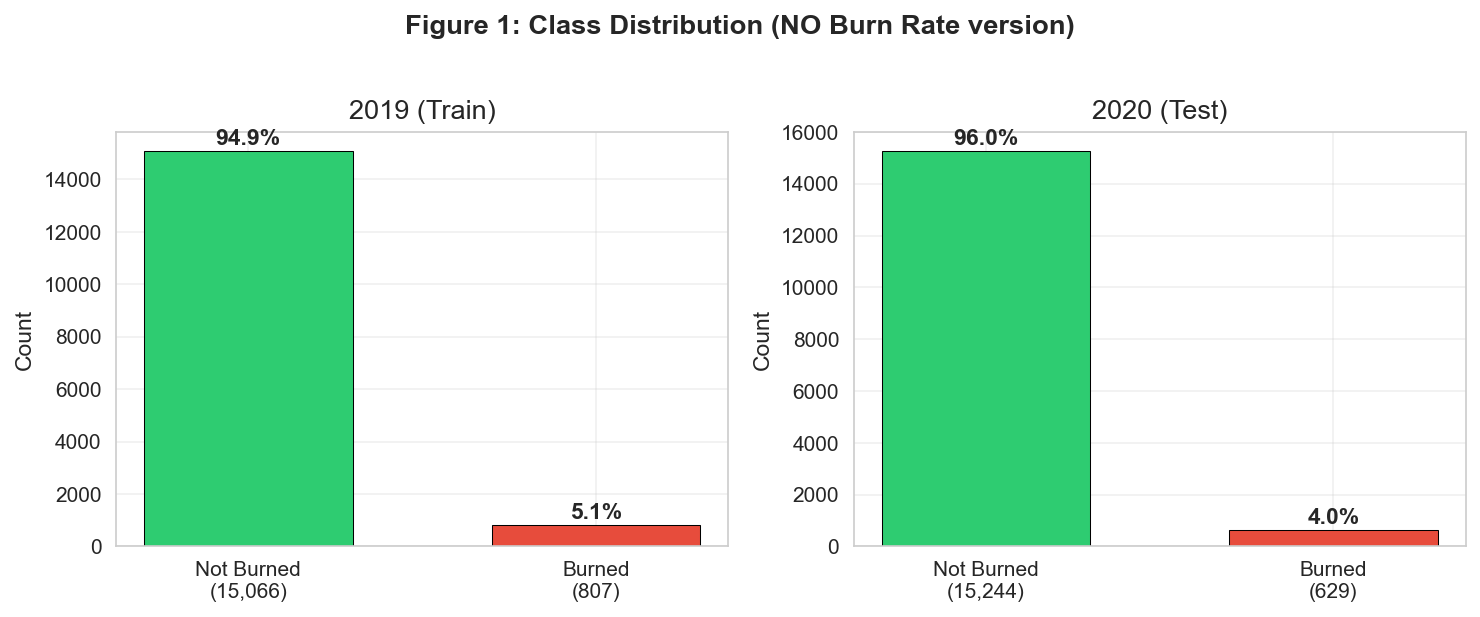

In [6]:
# ============================================================================
# Section 3: EDA & Visualizations
# ============================================================================

# --- Figure 1: Class Distribution 2019 vs 2020 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (year, y, n_pos) in zip(axes, [
    ("2019 (Train)", y_2019, n_pos_19),
    ("2020 (Test)",  y_2020, n_pos_20)
]):
    counts = [len(y) - n_pos, n_pos]
    labels = [f"Not Burned\n({counts[0]:,})", f"Burned\n({counts[1]:,})"]
    colors = ["#2ecc71", "#e74c3c"]
    bars = ax.bar([0, 1], counts, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_ylabel("Count")
    ax.set_title(f"{year}")
    for bar, count in zip(bars, counts):
        pct = count / len(y) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{pct:.1f}%", ha='center', va='bottom', fontweight='bold')

fig.suptitle("Figure 1: Class Distribution (NO Burn Rate version)", fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig01_class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

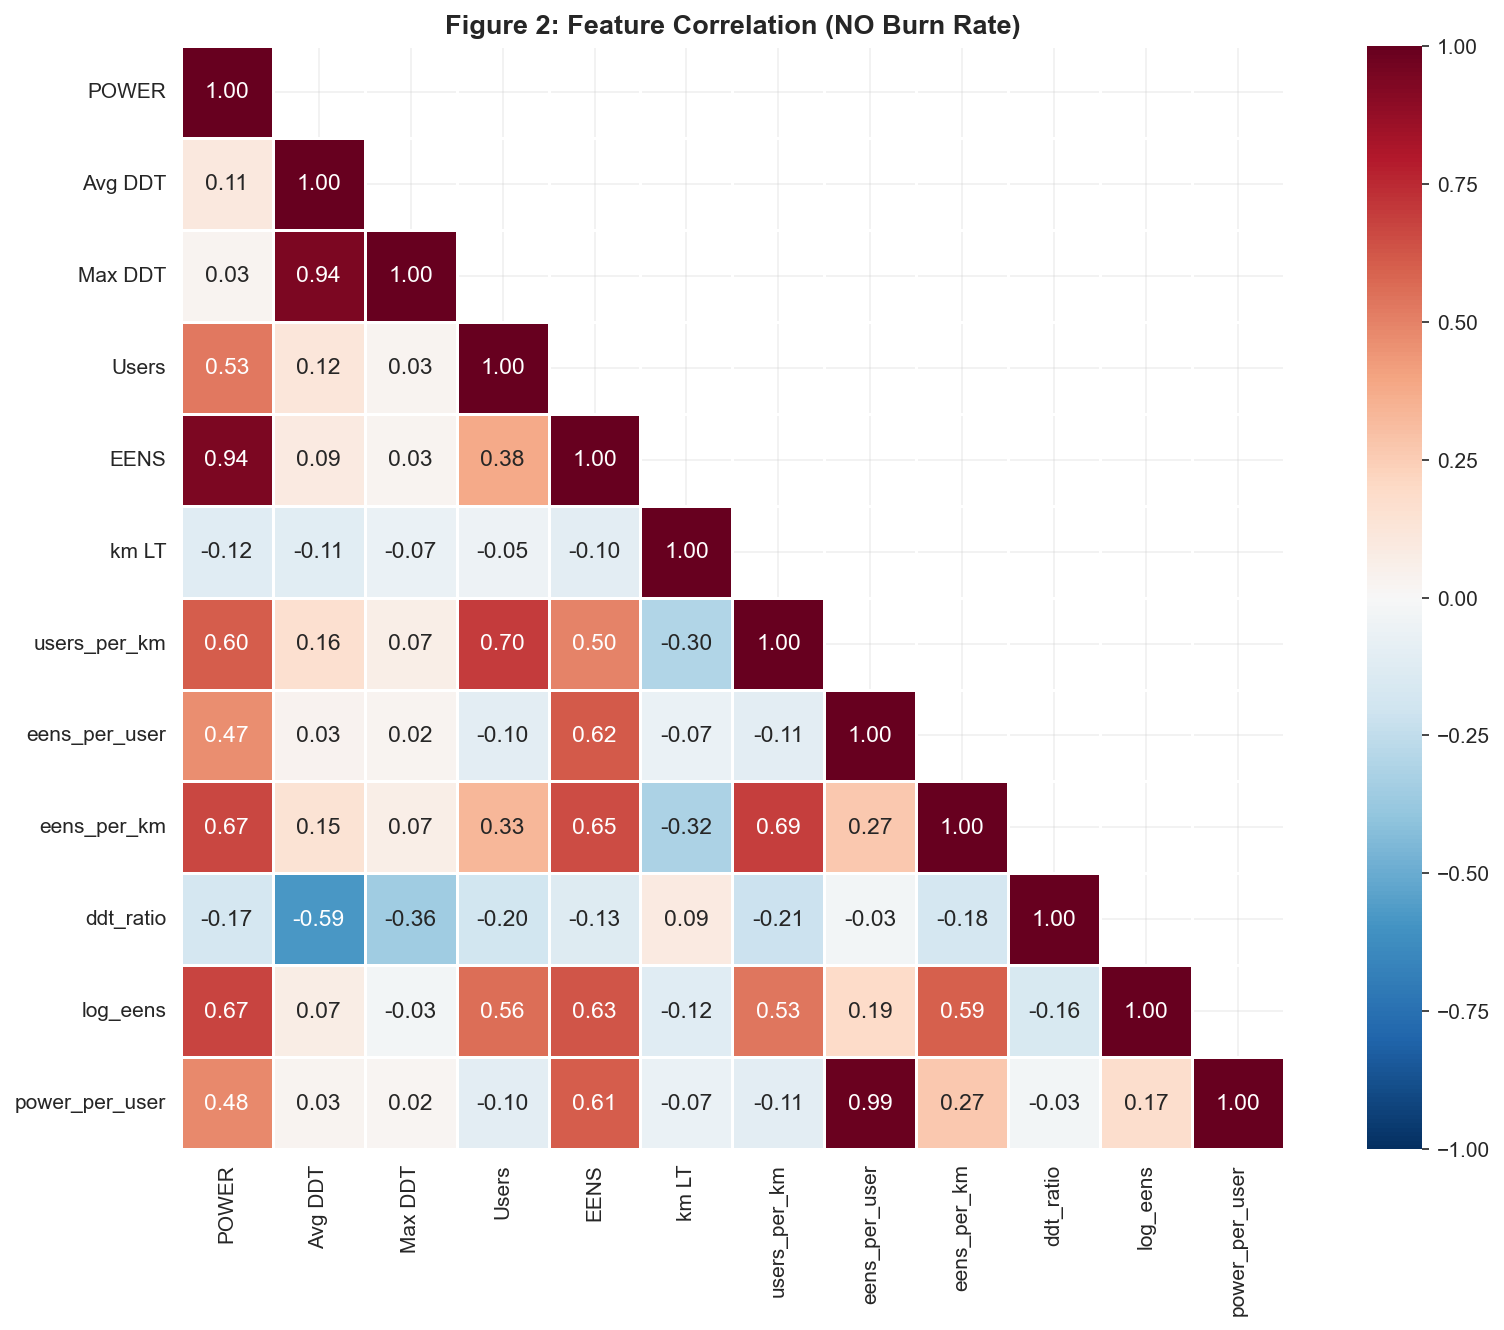

In [7]:
# --- Figure 2: Feature Correlation Heatmap ---
numeric_df = X_2019[num_cols].copy()
# Shorten column names for readability
short_names = {
    POWER_COL: "POWER",
    AVG_DDT: "Avg DDT",
    MAX_DDT: "Max DDT",
    USERS_COL: "Users",
    EENS_COL: "EENS",
    KM_COL: "km LT",
}
disp_names = [short_names.get(c, c) for c in numeric_df.columns]

corr = numeric_df.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=disp_names, yticklabels=disp_names,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Figure 2: Feature Correlation (NO Burn Rate)", fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig02_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

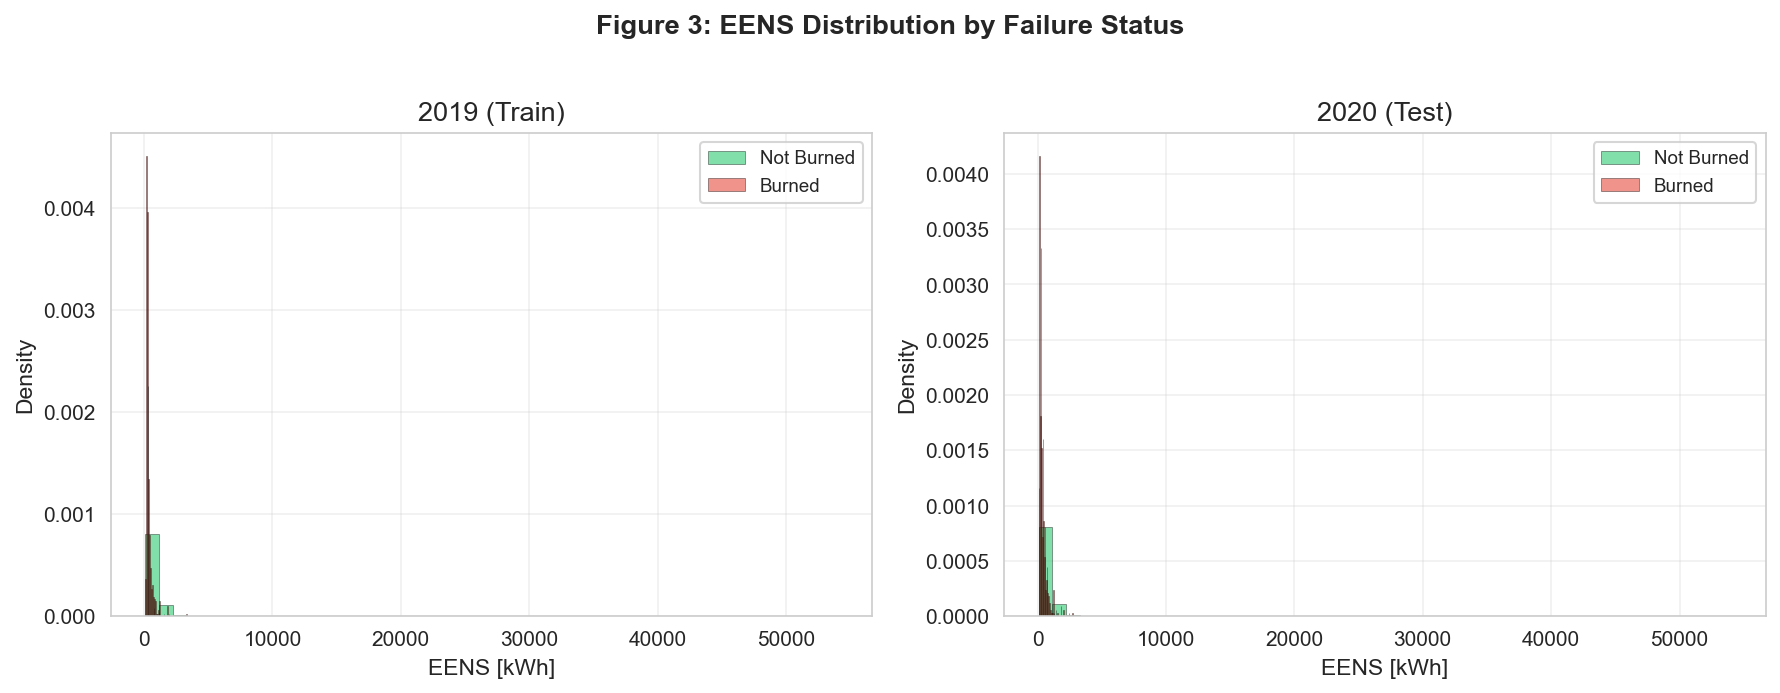

In [8]:
# --- Figure 3: EENS Distribution by Failure Status ---
# (Replaces the Burn Rate distribution figure from the full-feature pipeline)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (label, X, y) in zip(axes, [
    ("2019 (Train)", X_2019, y_2019),
    ("2020 (Test)",  X_2020, y_2020),
]):
    for cls, color, lbl in [(0, '#2ecc71', 'Not Burned'), (1, '#e74c3c', 'Burned')]:
        subset = X.loc[y == cls, EENS_COL]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=lbl,
                density=True, edgecolor='black', linewidth=0.3)
    ax.set_xlabel("EENS [kWh]")
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.legend()

fig.suptitle("Figure 3: EENS Distribution by Failure Status", fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig03_eens_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

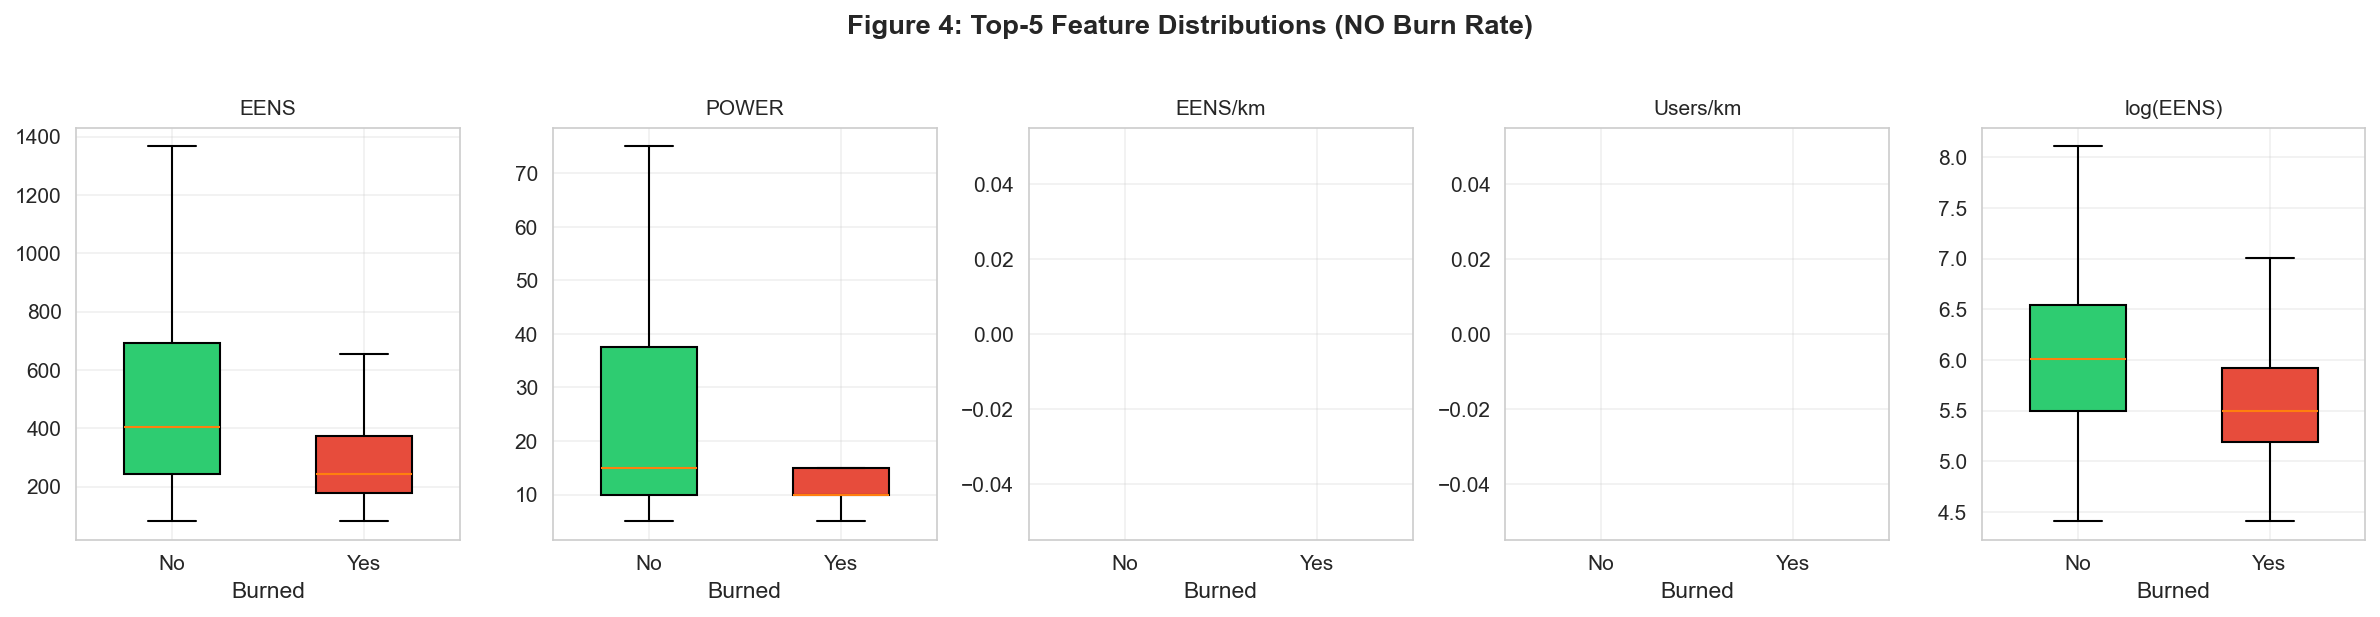

In [9]:
# --- Figure 4: Top-5 Feature Box Plots by Class (without burn rate) ---
top5_features = [EENS_COL, POWER_COL, "eens_per_km", "users_per_km", "log_eens"]
top5_short = ["EENS", "POWER", "EENS/km", "Users/km", "log(EENS)"]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
plot_df = X_2019.copy()
plot_df["Burned"] = y_2019.values

for ax, feat, short in zip(axes, top5_features, top5_short):
    if feat not in plot_df.columns:
        ax.set_visible(False)
        continue
    data_0 = plot_df.loc[plot_df["Burned"] == 0, feat]
    data_1 = plot_df.loc[plot_df["Burned"] == 1, feat]
    bp = ax.boxplot([data_0, data_1], labels=["No", "Yes"], patch_artist=True,
                    widths=0.5, showfliers=False)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_title(short, fontsize=10)
    ax.set_xlabel("Burned")

fig.suptitle("Figure 4: Top-5 Feature Distributions (NO Burn Rate)", fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig04_boxplots_top5.png", dpi=300, bbox_inches='tight')
plt.show()

---
## Section 4: Preprocessing Pipeline

- `ColumnTransformer` with `OneHotEncoder` for categoricals and `StandardScaler` for numerics
- **Temporal split**: Train = 2019, Test = 2020 (zero leakage)
- Within 2019: 60% train / 20% calibration / 20% validation (stratified)
- Preprocessor fit on 2019 training fold ONLY

In [10]:
# ============================================================================
# Section 4: Preprocessing Pipeline
# ============================================================================

def make_preprocessor(num_cols, cat_cols):
    """Build ColumnTransformer with proper OHE for categoricals."""
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop"
    )


# ── Within-2019 split: 60% train / 20% calibration / 20% validation ────────
X_train_full, X_val_2019, y_train_full, y_val_2019 = train_test_split(
    X_2019, y_2019, test_size=0.20, random_state=SEED, stratify=y_2019
)
X_train_2019, X_calib_2019, y_train_2019, y_calib_2019 = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)  # 0.25 of 80% = 20% of total

print(f"2019 Train:       {len(X_train_2019):,} (pos: {y_train_2019.sum()})")
print(f"2019 Calibration: {len(X_calib_2019):,} (pos: {y_calib_2019.sum()})")
print(f"2019 Validation:  {len(X_val_2019):,} (pos: {y_val_2019.sum()})")
print(f"2020 Test:        {len(X_2020):,} (pos: {y_2020.sum()})")

# ── Fit preprocessor on 2019 TRAIN fold ONLY ───────────────────────────────
preprocessor = make_preprocessor(num_cols, cat_cols)
preprocessor.fit(X_train_2019)

X_train_pp = preprocessor.transform(X_train_2019)
X_calib_pp = preprocessor.transform(X_calib_2019)
X_val_pp   = preprocessor.transform(X_val_2019)
X_test_pp  = preprocessor.transform(X_2020)

# Get feature names after OHE
ohe_feature_names = preprocessor.get_feature_names_out()
print(f"\nTransformed feature dimension: {X_train_pp.shape[1]}")
print(f"No data leakage: preprocessor fit only on 2019 train fold ({len(X_train_2019):,} rows)")

2019 Train:       9,523 (pos: 484)
2019 Calibration: 3,175 (pos: 162)
2019 Validation:  3,175 (pos: 161)
2020 Test:        15,873 (pos: 629)

Transformed feature dimension: 39
No data leakage: preprocessor fit only on 2019 train fold (9,523 rows)


---
## Section 5: SMOTE (Training Data Only)

Compare three imbalance-handling strategies:
1. No resampling (baseline)
2. SMOTE on training fold
3. Class weights (`class_weight='balanced'`)

**Paper Table 2**: Resampling strategy comparison.

In [11]:
# ============================================================================
# Section 5: SMOTE Comparison
# ============================================================================

# Apply SMOTE to training fold only
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pp, y_train_2019)

print(f"Before SMOTE: {len(X_train_pp):,} samples (pos: {y_train_2019.sum()}, neg: {(y_train_2019==0).sum()})")
print(f"After SMOTE:  {len(X_train_smote):,} samples (pos: {y_train_smote.sum()}, neg: {(y_train_smote==0).sum()})")

# Quick comparison: LogReg with 3 strategies on validation set
strategies = {
    'No resampling': (X_train_pp, y_train_2019, {}),
    'SMOTE':         (X_train_smote, y_train_smote, {}),
    'Class weights': (X_train_pp, y_train_2019, {'class_weight': 'balanced'}),
}

print("\nTABLE 2: Resampling Strategy Comparison (Logistic Regression on Validation Set)")
print(f"{'Strategy':<20s} {'ROC-AUC':>10s} {'PR-AUC':>10s} {'F2':>10s}")
print("-" * 55)

smote_results = []
for name, (Xtr, ytr, kwargs) in strategies.items():
    lr = LogisticRegression(max_iter=5000, solver='liblinear', random_state=SEED, **kwargs)
    lr.fit(Xtr, ytr)
    proba = lr.predict_proba(X_val_pp)[:, 1]
    roc = roc_auc_score(y_val_2019, proba)
    pr  = average_precision_score(y_val_2019, proba)
    # F2 at optimal threshold
    best_f2 = max(
        fbeta_score(y_val_2019, (proba >= t).astype(int), beta=2, zero_division=0)
        for t in np.linspace(0.01, 0.99, 99)
    )
    smote_results.append({'Strategy': name, 'ROC-AUC': roc, 'PR-AUC': pr, 'F2': best_f2})
    print(f"{name:<20s} {roc:>10.4f} {pr:>10.4f} {best_f2:>10.4f}")

table2 = pd.DataFrame(smote_results)
print("\nSMOTE applied ONLY to training data. Validation and test sets are untouched.")

Before SMOTE: 9,523 samples (pos: 484, neg: 9039)
After SMOTE:  18,078 samples (pos: 9039, neg: 9039)

TABLE 2: Resampling Strategy Comparison (Logistic Regression on Validation Set)
Strategy                ROC-AUC     PR-AUC         F2
-------------------------------------------------------
No resampling            0.7968     0.2524     0.3925
SMOTE                    0.7982     0.2508     0.4073
Class weights            0.8063     0.2429     0.4142

SMOTE applied ONLY to training data. Validation and test sets are untouched.


---
## Section 6: Model Training & Hyperparameter Tuning

Six models with `RandomizedSearchCV(scoring='average_precision', cv=StratifiedKFold(5))`:
1. SVM (RBF) - direct comparison to Alvarez/Vita
2. Logistic Regression - interpretable baseline
3. Random Forest - robust ensemble
4. Gradient Boosting - sklearn GB
5. XGBoost - modern boosting
6. LightGBM - fast gradient boosting

In [12]:
# ============================================================================
# Section 6: Model Training & Hyperparameter Tuning
# ============================================================================

pos_weight = (y_train_2019 == 0).sum() / max((y_train_2019 == 1).sum(), 1)
print(f"Class imbalance ratio: {pos_weight:.1f}:1")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

model_configs = {
    'SVM (RBF)': {
        'estimator': SVC(kernel='rbf', probability=True, class_weight='balanced',
                         random_state=SEED, cache_size=1000),
        'params': {
            'C': [0.1, 1, 10, 50],
            'gamma': ['scale', 'auto', 0.01, 0.001],
        },
        'use_smote': False,
    },
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=5000, solver='liblinear',
                                        class_weight='balanced', random_state=SEED),
        'params': {
            'C': np.logspace(-3, 2, 15),
            'penalty': ['l1', 'l2'],
        },
        'use_smote': False,
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                            random_state=SEED, n_jobs=-1),
        'params': {
            'max_depth': [None, 8, 16, 24],
            'min_samples_leaf': [1, 3, 5, 10],
            'min_samples_split': [2, 5, 10],
        },
        'use_smote': False,
    },
    'Gradient Boosting': {
        'estimator': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'n_estimators': [200, 400, 600],
            'learning_rate': [0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5],
            'subsample': [0.8, 0.9, 1.0],
        },
        'use_smote': True,
    },
    'XGBoost': {
        'estimator': XGBClassifier(
            random_state=SEED, n_estimators=500, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, eval_metric='logloss',
            tree_method='hist', scale_pos_weight=pos_weight,
        ),
        'params': {
            'max_depth': [3, 5, 7],
            'min_child_weight': [1, 5, 10],
            'reg_alpha': [0, 0.1, 1],
            'reg_lambda': [1, 5, 10],
        },
        'use_smote': False,
    },
    'LightGBM': {
        'estimator': LGBMClassifier(
            random_state=SEED, n_estimators=500, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, scale_pos_weight=pos_weight,
            min_child_samples=50, num_leaves=31, max_depth=6, verbose=-1,
        ),
        'params': {
            'num_leaves': [15, 31, 63],
            'min_child_samples': [20, 50, 100],
            'max_depth': [4, 6, 8],
            'reg_alpha': [0, 0.1, 1],
        },
        'use_smote': False,
    },
}

print(f"Training {len(model_configs)} models with RandomizedSearchCV (scoring=average_precision)...\n")

Class imbalance ratio: 18.7:1
Training 6 models with RandomizedSearchCV (scoring=average_precision)...



In [13]:
# Train all models
trained_models = {}  # name -> best fitted estimator

for name, config in model_configs.items():
    print(f"\n{'='*60}")
    print(f"[MODEL] {name}")

    # Choose training data based on SMOTE strategy
    if config['use_smote']:
        Xtr, ytr = X_train_smote, y_train_smote
        print(f"  Using SMOTE data ({len(Xtr):,} samples)")
    else:
        Xtr, ytr = X_train_pp, y_train_2019
        print(f"  Using original data with class_weight ({len(Xtr):,} samples)")

    rs = RandomizedSearchCV(
        estimator=config['estimator'],
        param_distributions=config['params'],
        n_iter=20,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        random_state=SEED,
        verbose=0,
    )
    rs.fit(Xtr, ytr)

    trained_models[name] = rs.best_estimator_

    # Quick validation check
    val_proba = rs.best_estimator_.predict_proba(X_val_pp)[:, 1]
    val_pr = average_precision_score(y_val_2019, val_proba)
    val_roc = roc_auc_score(y_val_2019, val_proba)

    print(f"  Best CV PR-AUC: {rs.best_score_:.4f}")
    print(f"  Validation PR-AUC: {val_pr:.4f} | ROC-AUC: {val_roc:.4f}")
    print(f"  Best params: {rs.best_params_}")

print("\n" + "="*60)
print("All models trained.")


[MODEL] SVM (RBF)
  Using original data with class_weight (9,523 samples)
  Best CV PR-AUC: 0.2512
  Validation PR-AUC: 0.2696 | ROC-AUC: 0.8254
  Best params: {'gamma': 'scale', 'C': 1}

[MODEL] Logistic Regression
  Using original data with class_weight (9,523 samples)
  Best CV PR-AUC: 0.2589
  Validation PR-AUC: 0.2356 | ROC-AUC: 0.8057
  Best params: {'penalty': 'l1', 'C': np.float64(8.483428982440726)}

[MODEL] Random Forest
  Using original data with class_weight (9,523 samples)
  Best CV PR-AUC: 0.3119
  Validation PR-AUC: 0.3250 | ROC-AUC: 0.8413
  Best params: {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_depth': 16}

[MODEL] Gradient Boosting
  Using SMOTE data (18,078 samples)
  Best CV PR-AUC: 0.9942
  Validation PR-AUC: 0.2470 | ROC-AUC: 0.8281
  Best params: {'subsample': 0.9, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.1}

[MODEL] XGBoost
  Using original data with class_weight (9,523 samples)
  Best CV PR-AUC: 0.2880
  Validation PR-AUC: 0.2940 | R

---
## Section 7: Probability Calibration

Apply `CalibratedClassifierCV` with `FrozenEstimator` on the held-out calibration fold.

**Paper Figure 5**: Calibration curves (reliability diagrams).

In [14]:
# ============================================================================
# Section 7: Probability Calibration
# ============================================================================

calibrated_models = {}

for name, model in trained_models.items():
    cal = CalibratedClassifierCV(estimator=FrozenEstimator(model), method='sigmoid')
    cal.fit(X_calib_pp, y_calib_2019)
    calibrated_models[name] = cal
    print(f"Calibrated: {name}")

print(f"\n{len(calibrated_models)} models calibrated using sigmoid method on calibration fold.")

Calibrated: SVM (RBF)
Calibrated: Logistic Regression
Calibrated: Random Forest
Calibrated: Gradient Boosting
Calibrated: XGBoost
Calibrated: LightGBM

6 models calibrated using sigmoid method on calibration fold.


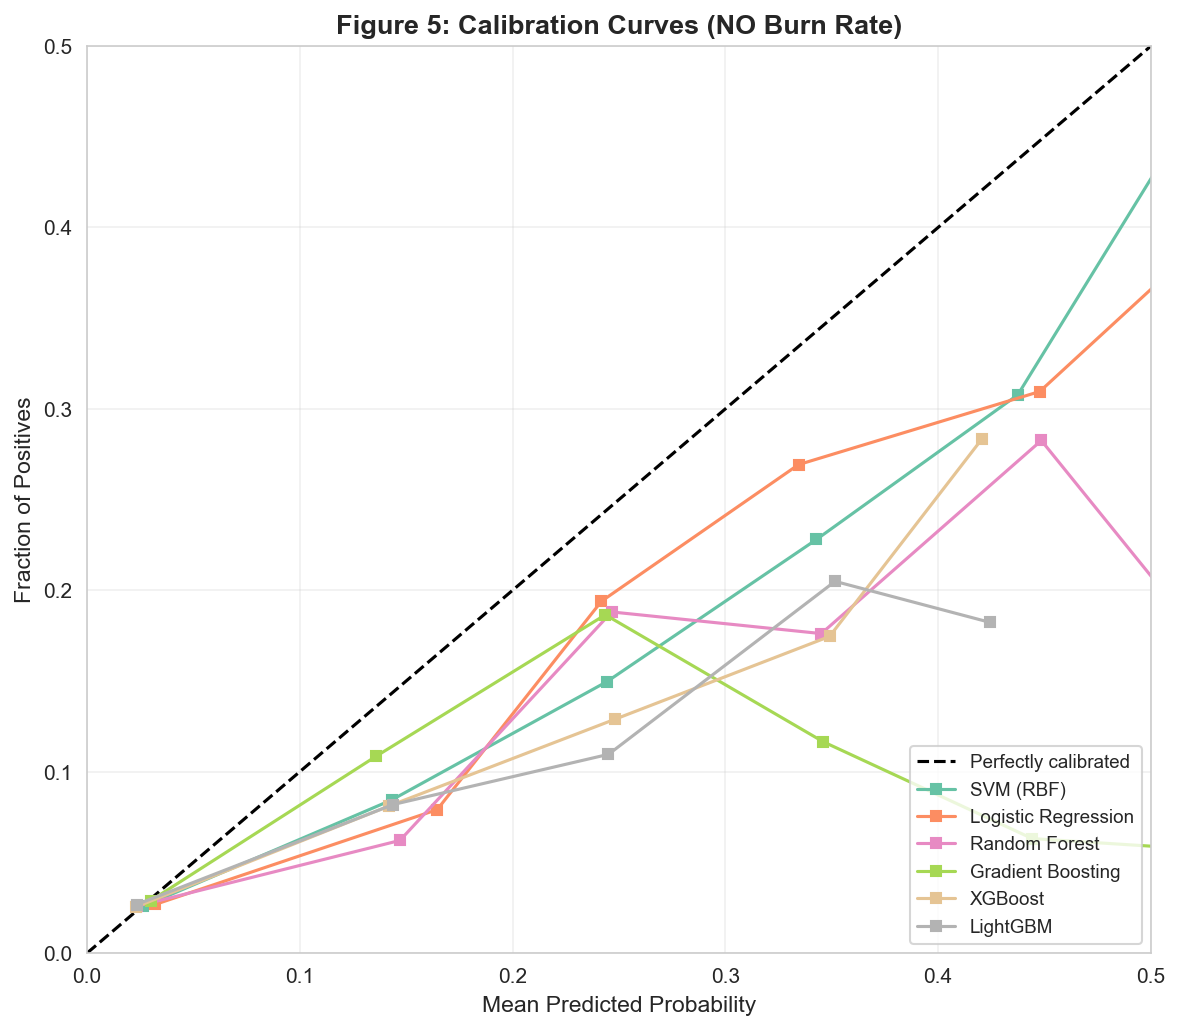

In [15]:
# --- Figure 5: Calibration Curves ---
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')

colors_cal = plt.cm.Set2(np.linspace(0, 1, len(calibrated_models)))

for (name, cal_model), color in zip(calibrated_models.items(), colors_cal):
    proba = cal_model.predict_proba(X_test_pp)[:, 1]
    fraction_pos, mean_pred = calibration_curve(y_2020, proba, n_bins=10, strategy='uniform')
    ax.plot(mean_pred, fraction_pos, 's-', color=color, label=name, markersize=5)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Figure 5: Calibration Curves (NO Burn Rate)', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 0.5])  # zoom into relevant range
ax.set_ylim([0, 0.5])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig05_calibration_curves.png", dpi=300, bbox_inches='tight')
plt.show()

---
## Section 8: Evaluation on 2020 Test Set

Comprehensive evaluation with multiple metrics, including a dummy classifier baseline.

**Paper Table 3**: Full model comparison.
**Paper Figures 6-8**: PR curves, ROC curves, confusion matrices.

In [16]:
# ============================================================================
# Section 8: Evaluation on 2020 Test Set
# ============================================================================

def optimize_threshold_f2(y_true, y_prob):
    """Find threshold maximizing F2 score."""
    best_t, best_f2 = 0.5, 0.0
    for t in np.linspace(0.01, 0.99, 99):
        pred = (y_prob >= t).astype(int)
        f2 = fbeta_score(y_true, pred, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2 = f2
            best_t = t
    return best_t, best_f2


def precision_recall_at_k(y_true, y_prob, k_pct):
    """Compute Precision@k% and Recall@k%."""
    n = len(y_true)
    k = max(1, int(n * k_pct / 100))
    top_k_idx = np.argsort(y_prob)[::-1][:k]
    top_k_true = np.array(y_true)[top_k_idx]
    prec = top_k_true.sum() / k
    rec = top_k_true.sum() / max(1, y_true.sum())
    lift = prec / max(1e-10, y_true.mean())
    return prec, rec, lift


# ── Dummy classifier baseline ──────────────────────────────────────────────
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_pp, y_train_2019)
dummy_pred = dummy.predict(X_test_pp)
print("DUMMY CLASSIFIER (predict all zeros):")
print(f"  Accuracy: {accuracy_score(y_2020, dummy_pred)*100:.2f}%")
print(f"  Recall:   {recall_score(y_2020, dummy_pred, zero_division=0)*100:.2f}%")
print(f"  F1:       {f1_score(y_2020, dummy_pred, zero_division=0):.4f}")
print("  --> This proves accuracy is MISLEADING at ~4% failure rate.\n")

DUMMY CLASSIFIER (predict all zeros):
  Accuracy: 96.04%
  Recall:   0.00%
  F1:       0.0000
  --> This proves accuracy is MISLEADING at ~4% failure rate.



In [17]:
# ── Evaluate all calibrated models on 2020 ─────────────────────────────────
eval_results = []

for name, cal_model in calibrated_models.items():
    proba = cal_model.predict_proba(X_test_pp)[:, 1]

    # Optimize threshold on validation, apply to test
    val_proba = cal_model.predict_proba(X_val_pp)[:, 1]
    best_t, _ = optimize_threshold_f2(y_val_2019, val_proba)

    y_pred = (proba >= best_t).astype(int)

    roc = roc_auc_score(y_2020, proba)
    pr  = average_precision_score(y_2020, proba)
    f2  = fbeta_score(y_2020, y_pred, beta=2, zero_division=0)
    f1  = f1_score(y_2020, y_pred, zero_division=0)
    acc = accuracy_score(y_2020, y_pred)
    prec = precision_score(y_2020, y_pred, zero_division=0)
    rec  = recall_score(y_2020, y_pred, zero_division=0)

    p1, r1, l1 = precision_recall_at_k(y_2020, proba, 1)
    p5, r5, l5 = precision_recall_at_k(y_2020, proba, 5)
    p10, r10, l10 = precision_recall_at_k(y_2020, proba, 10)

    eval_results.append({
        'Model': name, 'ROC-AUC': roc, 'PR-AUC': pr, 'F2': f2, 'F1': f1,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'Threshold': best_t,
        'P@1%': p1, 'R@1%': r1, 'Lift@1%': l1,
        'P@5%': p5, 'R@5%': r5, 'Lift@5%': l5,
        'P@10%': p10, 'R@10%': r10, 'Lift@10%': l10,
    })

results_df = pd.DataFrame(eval_results).sort_values('PR-AUC', ascending=False)

# TABLE 3: Model Comparison
print("TABLE 3: Model Comparison on 2020 Test Set (NO Burn Rate)")
print("=" * 100)
display_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'F2', 'F1', 'Precision', 'Recall', 'Lift@5%', 'Threshold']
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest model by PR-AUC: {best_model_name}")

TABLE 3: Model Comparison on 2020 Test Set (NO Burn Rate)
              Model  ROC-AUC  PR-AUC     F2     F1  Precision  Recall  Lift@5%  Threshold
Logistic Regression   0.7268  0.1531 0.2823 0.1646     0.0972  0.5390   5.6962     0.0500
          SVM (RBF)   0.7254  0.1404 0.2942 0.1824     0.1117  0.4976   5.1234     0.0700
            XGBoost   0.7311  0.1329 0.2902 0.2029     0.1351  0.4070   4.9007     0.1200
      Random Forest   0.7321  0.1288 0.3021 0.2114     0.1410  0.4229   5.2825     0.0900
           LightGBM   0.7281  0.1143 0.2737 0.1871     0.1225  0.3959   4.4870     0.1100
  Gradient Boosting   0.7060  0.0951 0.2679 0.1814     0.1180  0.3927   3.6596     0.0900

Best model by PR-AUC: Logistic Regression


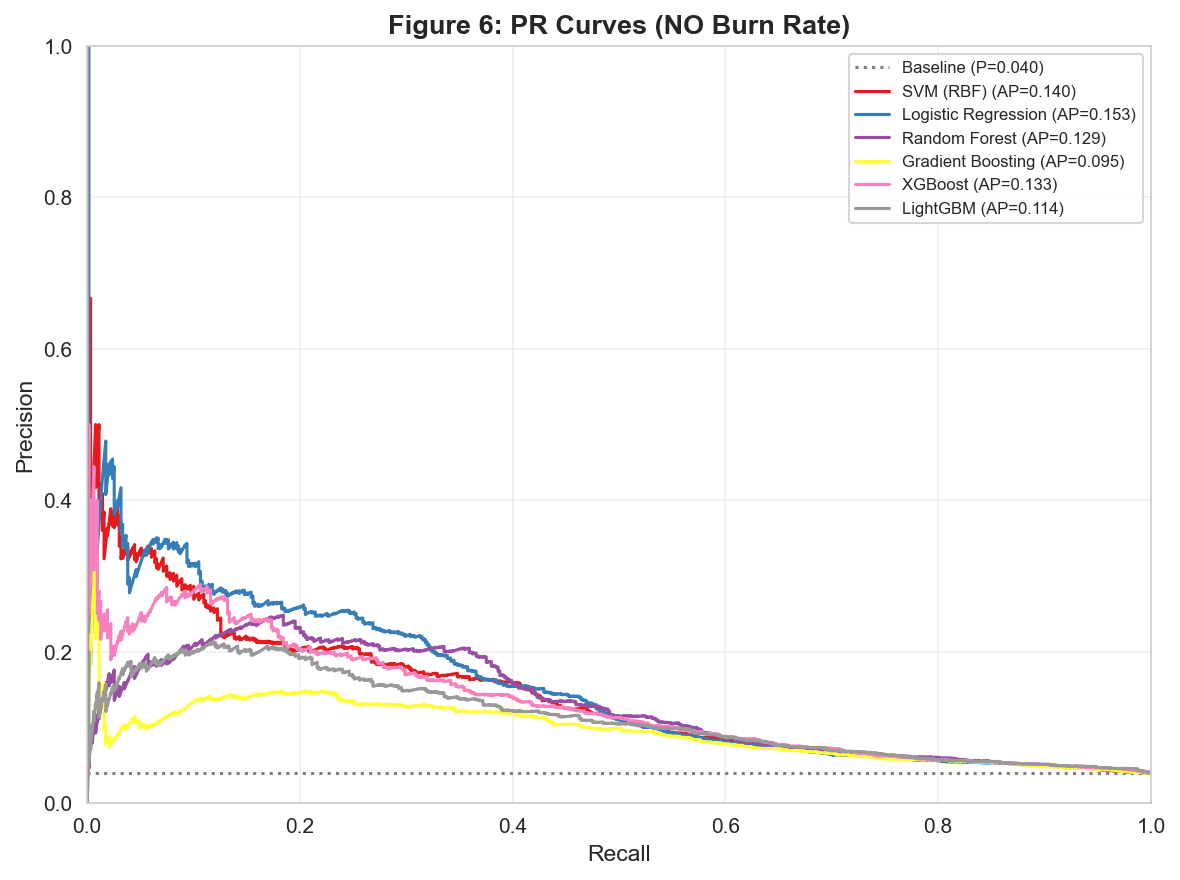

In [18]:
# --- Figure 6: Precision-Recall Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set1(np.linspace(0, 1, len(calibrated_models)))

baseline_pr = y_2020.mean()
ax.axhline(y=baseline_pr, color='gray', linestyle=':', label=f'Baseline (P={baseline_pr:.3f})')

for (name, cal_model), color in zip(calibrated_models.items(), colors):
    proba = cal_model.predict_proba(X_test_pp)[:, 1]
    precision, recall, _ = precision_recall_curve(y_2020, proba)
    ap = average_precision_score(y_2020, proba)
    ax.plot(recall, precision, color=color, label=f'{name} (AP={ap:.3f})', linewidth=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Figure 6: PR Curves (NO Burn Rate)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig06_pr_curves.png", dpi=300, bbox_inches='tight')
plt.show()

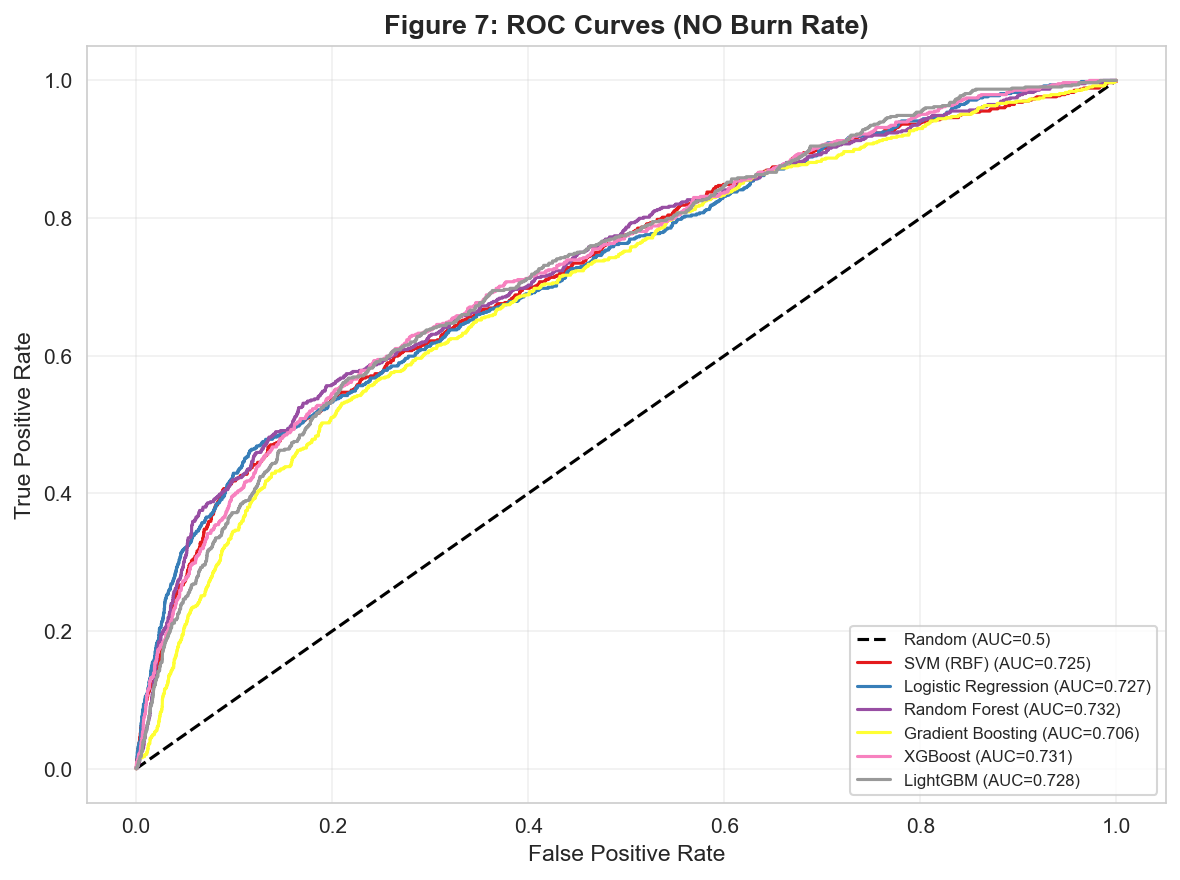

In [19]:
# --- Figure 7: ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')

for (name, cal_model), color in zip(calibrated_models.items(), colors):
    proba = cal_model.predict_proba(X_test_pp)[:, 1]
    fpr, tpr, _ = roc_curve(y_2020, proba)
    auc = roc_auc_score(y_2020, proba)
    ax.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 7: ROC Curves (NO Burn Rate)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig07_roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

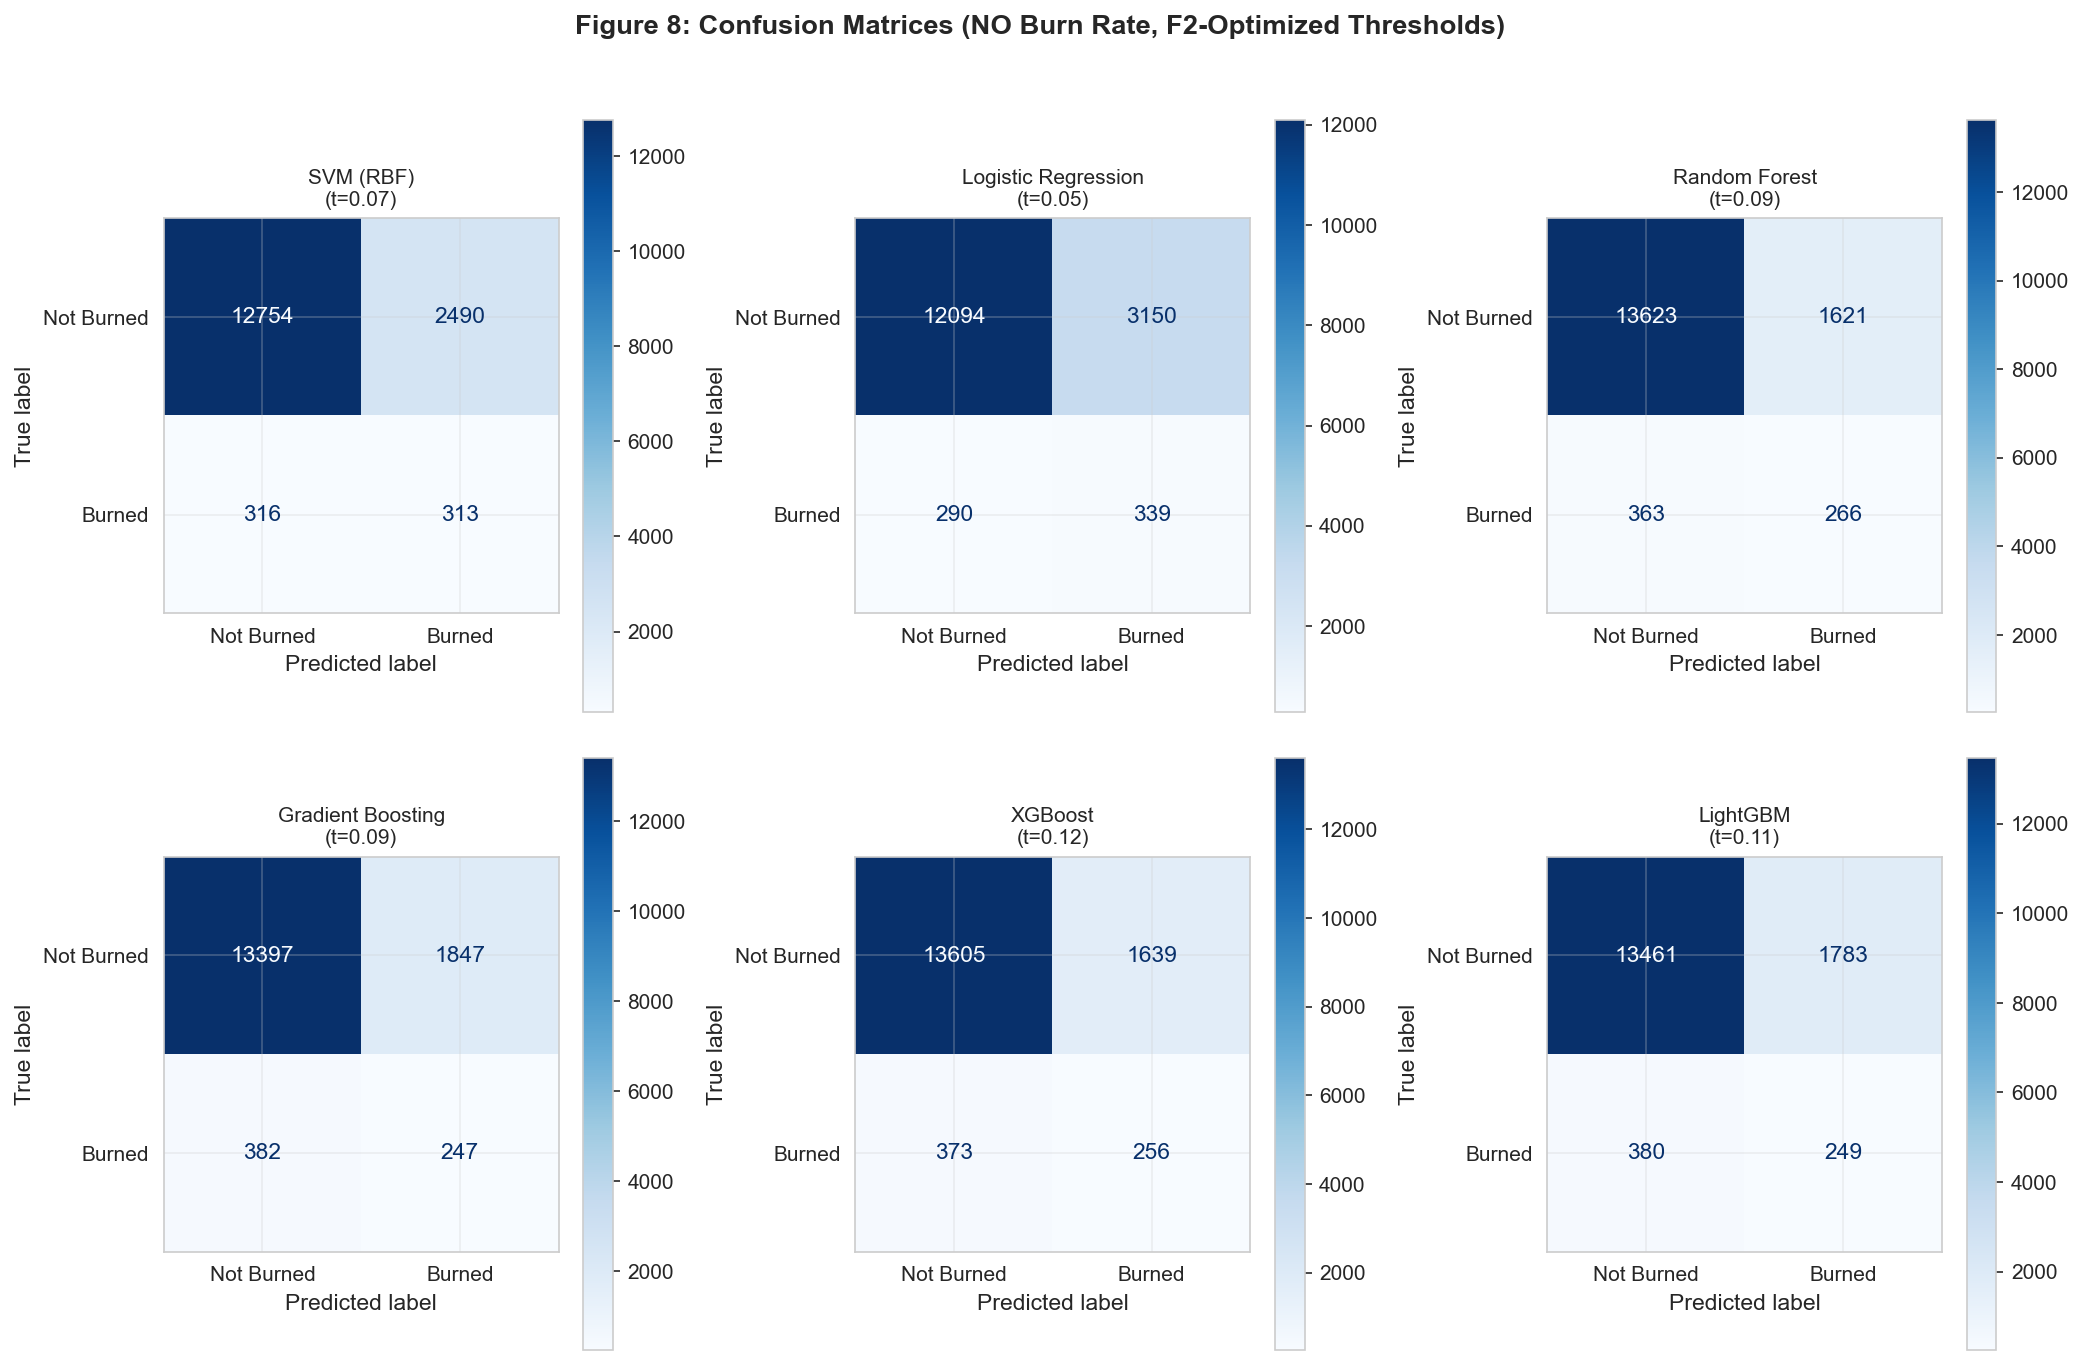

In [20]:
# --- Figure 8: Confusion Matrices Grid ---
n_models = len(calibrated_models)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (name, cal_model) in enumerate(calibrated_models.items()):
    proba = cal_model.predict_proba(X_test_pp)[:, 1]
    val_proba = cal_model.predict_proba(X_val_pp)[:, 1]
    best_t, _ = optimize_threshold_f2(y_val_2019, val_proba)
    y_pred = (proba >= best_t).astype(int)

    cm = confusion_matrix(y_2020, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Not Burned', 'Burned']).plot(
        ax=axes[idx], cmap='Blues', values_format='d'
    )
    axes[idx].set_title(f"{name}\n(t={best_t:.2f})", fontsize=10)

# Hide extra subplots if any
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Figure 8: Confusion Matrices (NO Burn Rate, F2-Optimized Thresholds)',
             fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig08_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

---
## Section 9: SHAP Explainability

SHAP analysis **without** Burn Rate — reveals which physical/operational features
the model relies on when historical failure data is unavailable.

**Paper Figure 9**: SHAP beeswarm plot
**Paper Figure 10**: SHAP dependence plot for top feature

In [21]:
# ============================================================================
# Section 9: SHAP Explainability
# ============================================================================

# Use best tree-based model for SHAP
tree_models = ['XGBoost', 'LightGBM', 'Random Forest', 'Gradient Boosting']
best_tree_name = results_df[results_df['Model'].isin(tree_models)].iloc[0]['Model']
print(f"Using {best_tree_name} for SHAP analysis")

shap_model = trained_models[best_tree_name]  # use uncalibrated for TreeExplainer

# Map OHE feature names back to readable names
feature_display_names = []
replacements = {
    AVG_DDT: 'Avg DDT',
    MAX_DDT: 'Max DDT',
    EENS_COL: 'EENS',
    USERS_COL: 'Users',
    KM_COL: 'km Network',
    POWER_COL: 'POWER',
}
for fname in ohe_feature_names:
    fname_str = str(fname)
    # Clean up sklearn prefixes
    for prefix in ['num__', 'cat__']:
        if fname_str.startswith(prefix):
            fname_str = fname_str[len(prefix):]
    # Shorten long names
    for long, short in replacements.items():
        fname_str = fname_str.replace(long, short)
    feature_display_names.append(fname_str)

print(f"Computing SHAP values on test set ({len(X_test_pp)} samples)...")

Using XGBoost for SHAP analysis
Computing SHAP values on test set (15873 samples)...


In [22]:
# Compute SHAP values
explainer = shap.TreeExplainer(shap_model)

# Use a subsample for speed if needed
shap_sample_size = min(2000, len(X_test_pp))
rng = np.random.RandomState(SEED)
shap_idx = rng.choice(len(X_test_pp), shap_sample_size, replace=False)
X_shap = X_test_pp[shap_idx]

shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values computed for {shap_sample_size} samples.")
print(f"SHAP matrix shape: {shap_values.shape}")

SHAP values computed for 2000 samples.
SHAP matrix shape: (2000, 39)


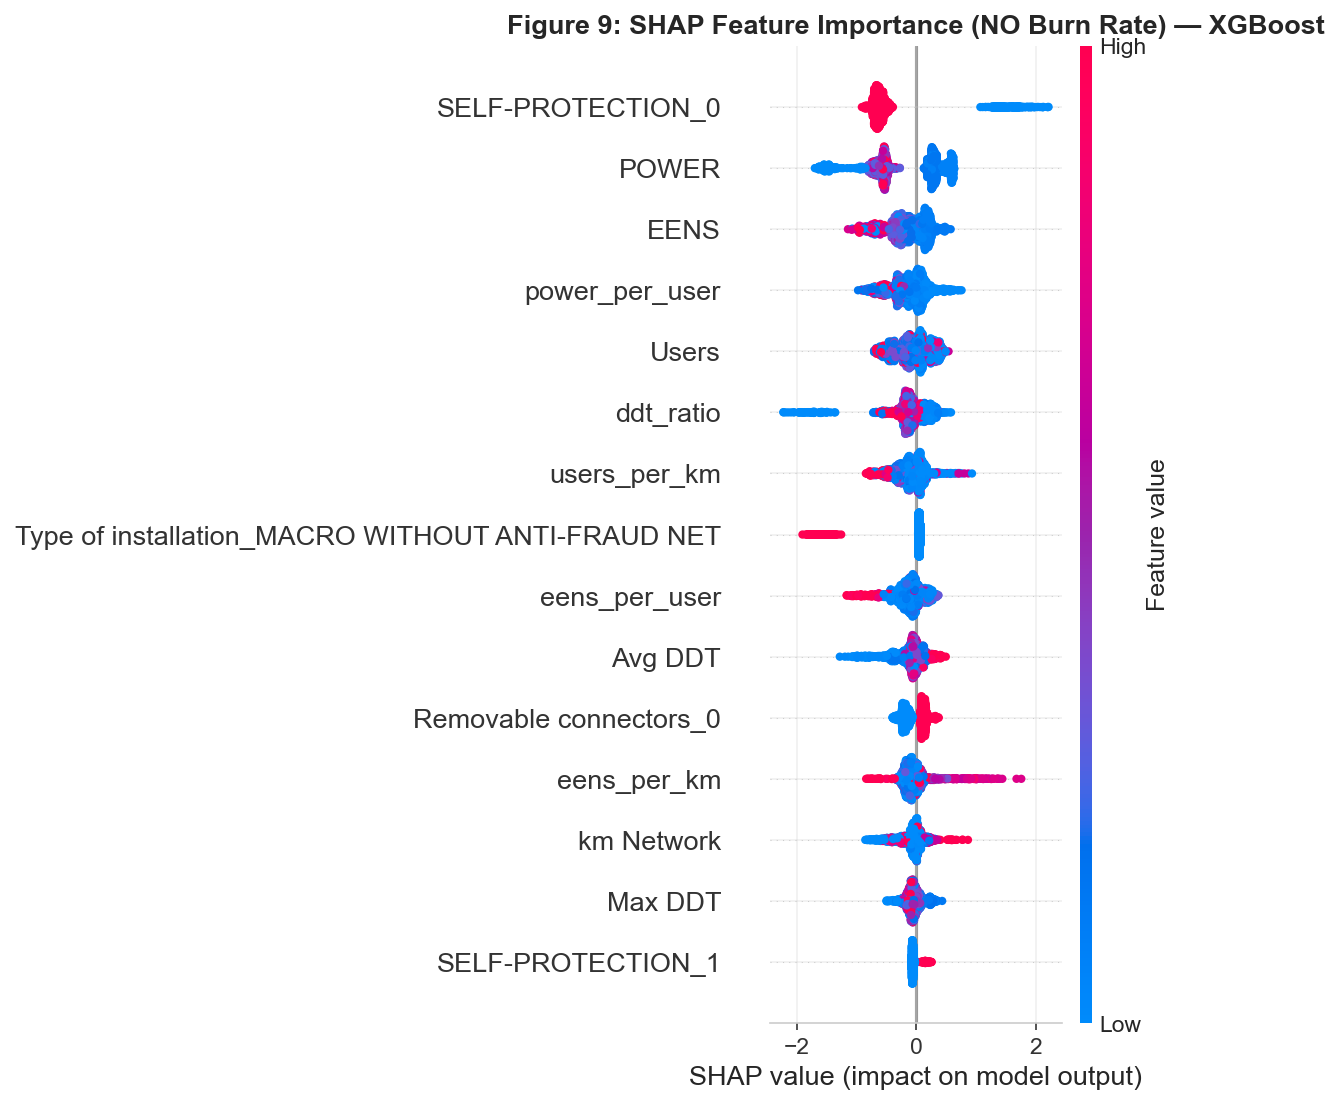

In [23]:
# --- Figure 9: SHAP Beeswarm Plot (Top 15 Features) ---
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_display_names,
    max_display=15,
    show=False,
)
plt.title(f'Figure 9: SHAP Feature Importance (NO Burn Rate) \u2014 {best_tree_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig09_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

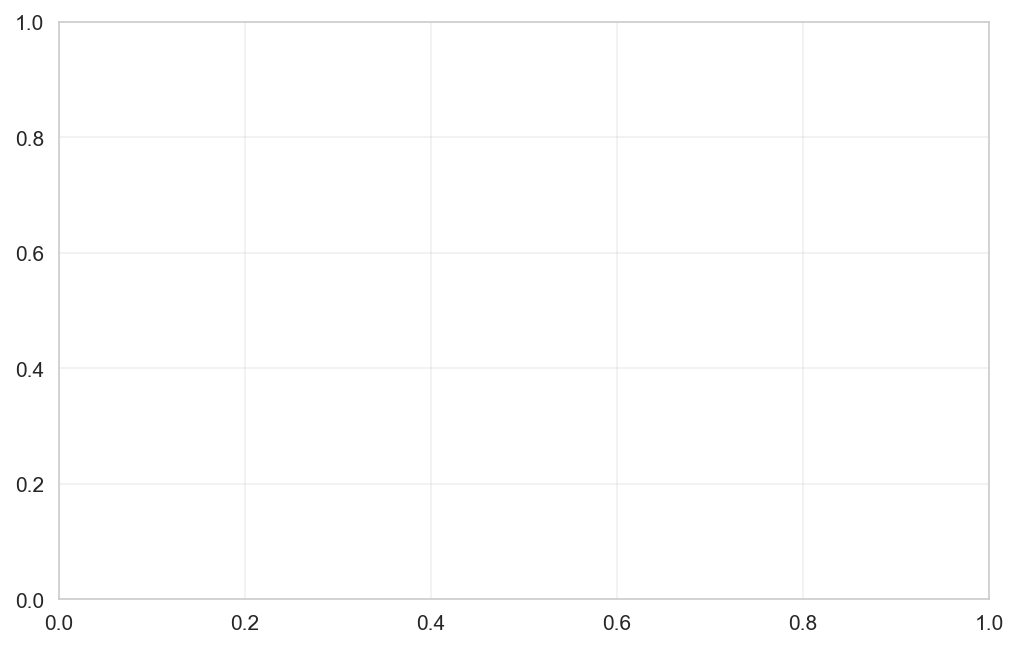

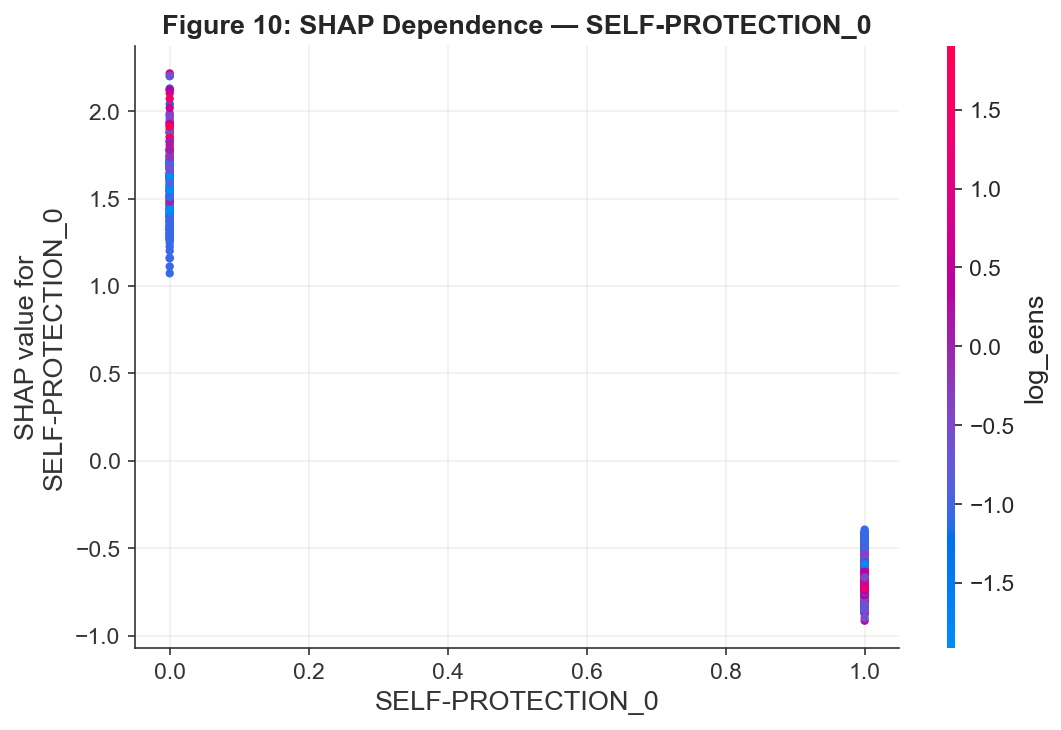

In [24]:
# --- Figure 10: SHAP Dependence Plot for Top Feature ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feat_idx = int(np.argmax(mean_abs_shap))

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(
    top_feat_idx, shap_values, X_shap,
    feature_names=feature_display_names,
    show=False,
)
plt.title(f'Figure 10: SHAP Dependence \u2014 {feature_display_names[top_feat_idx]}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig10_shap_dependence_top.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# Grouped SHAP importance (aggregate one-hot features back to original)
grouped_importance = {}

for i, fname in enumerate(feature_display_names):
    # Group one-hot encoded features by original feature name
    base_name = fname
    for cat in KNOWN_CATS:
        if fname.startswith(cat + '_') or fname.startswith(cat):
            base_name = cat
            break
    grouped_importance[base_name] = grouped_importance.get(base_name, 0) + mean_abs_shap[i]

# Sort and display
sorted_importance = sorted(grouped_importance.items(), key=lambda x: x[1], reverse=True)
print("Grouped SHAP Feature Importance (aggregated one-hot features):")
print(f"{'Feature':<35s} {'Mean |SHAP|':>12s}")
print("-" * 50)
for feat, imp in sorted_importance[:15]:
    print(f"{feat:<35s} {imp:>12.4f}")

Grouped SHAP Feature Importance (aggregated one-hot features):
Feature                              Mean |SHAP|
--------------------------------------------------
SELF-PROTECTION                           0.7858
POWER                                     0.5600
EENS                                      0.2711
Type of installation                      0.2616
power_per_user                            0.2347
Users                                     0.2254
ddt_ratio                                 0.2204
users_per_km                              0.2023
eens_per_user                             0.1940
Avg DDT                                   0.1820
Removable connectors                      0.1757
eens_per_km                               0.1582
km Network                                0.1450
Max DDT                                   0.1044
Type of clients                           0.0712


---
## Section 10: Economic Risk Framework

Transform binary predictions into calibrated risk scores:
**Expected Loss = P(failure) x Replacement Cost(kVA)**

**Paper Figure 11**: Cost-benefit curve
**Paper Table 4**: Top 10 highest-risk transformers

In [26]:
# ============================================================================
# Section 10: Economic Risk Framework
# ============================================================================

# Cost function: base cost proportional to POWER (kVA)
# Using Alvarez's figures: average replacement ~560,000 COP per transformer
# Larger transformers cost more
COST_BASE_COP = 560_000  # COP per failure (average)
COST_INSPECTION_COP = 50_000  # COP per preventive inspection

# Scale cost by power rating relative to median
power_2020 = df_2020[POWER_COL].values
median_power = np.median(power_2020[power_2020 > 0])
replacement_cost = COST_BASE_COP * (power_2020 / median_power).clip(0.5, 5.0)

# Get calibrated probabilities from best model
best_cal_model = calibrated_models[best_model_name]
p_fail = best_cal_model.predict_proba(X_test_pp)[:, 1]

# Expected Loss per transformer
expected_loss = p_fail * replacement_cost

# Build risk ranking dataframe
risk_df = pd.DataFrame({
    'Transformer_ID': range(1, len(df_2020) + 1),
    'P_failure': p_fail,
    'Power_kVA': power_2020,
    'Replacement_Cost_COP': replacement_cost,
    'Expected_Loss_COP': expected_loss,
    'Actual_Burned': y_2020.values,
})
risk_df = risk_df.sort_values('Expected_Loss_COP', ascending=False).reset_index(drop=True)

# TABLE 4: Top 10 Highest-Risk Transformers
print("TABLE 4: Top 10 Highest-Risk Transformers (NO Burn Rate)")
print("=" * 90)
top10 = risk_df.head(10).copy()
top10['Rank'] = range(1, 11)
top10['Actual'] = top10['Actual_Burned'].map({0: 'No', 1: 'YES'})
display_cols_t4 = ['Rank', 'Transformer_ID', 'P_failure', 'Power_kVA',
                   'Replacement_Cost_COP', 'Expected_Loss_COP', 'Actual']
print(top10[display_cols_t4].to_string(index=False, float_format='{:.4f}'.format))

# Summary statistics
total_expected_loss = risk_df['Expected_Loss_COP'].sum()
total_actual_cost = risk_df.loc[risk_df['Actual_Burned'] == 1, 'Replacement_Cost_COP'].sum()
print(f"\nTotal Expected Loss (all 15,873): {total_expected_loss:,.0f} COP")
print(f"Total Actual Replacement Cost (629 failures): {total_actual_cost:,.0f} COP")

TABLE 4: Top 10 Highest-Risk Transformers (NO Burn Rate)
 Rank  Transformer_ID  P_failure  Power_kVA  Replacement_Cost_COP  Expected_Loss_COP Actual
    1            8510     0.4858    25.0000           933333.3333        453453.9241     No
    2            7012     0.2635    45.0000          1680000.0000        442612.9167     No
    3            8009     0.7346    15.0000           560000.0000        411384.2165     No
    4            5744     0.4247    25.0000           933333.3333        396351.4521     No
    5            9606     0.2769    37.5000          1400000.0000        387716.7208    YES
    6           14172     0.4131    25.0000           933333.3333        385519.7113     No
    7           14567     0.2732    37.5000          1400000.0000        382506.9518     No
    8           12383     0.3819    25.0000           933333.3333        356486.4021     No
    9           15144     0.6300    15.0000           560000.0000        352774.2406     No
   10            5510  

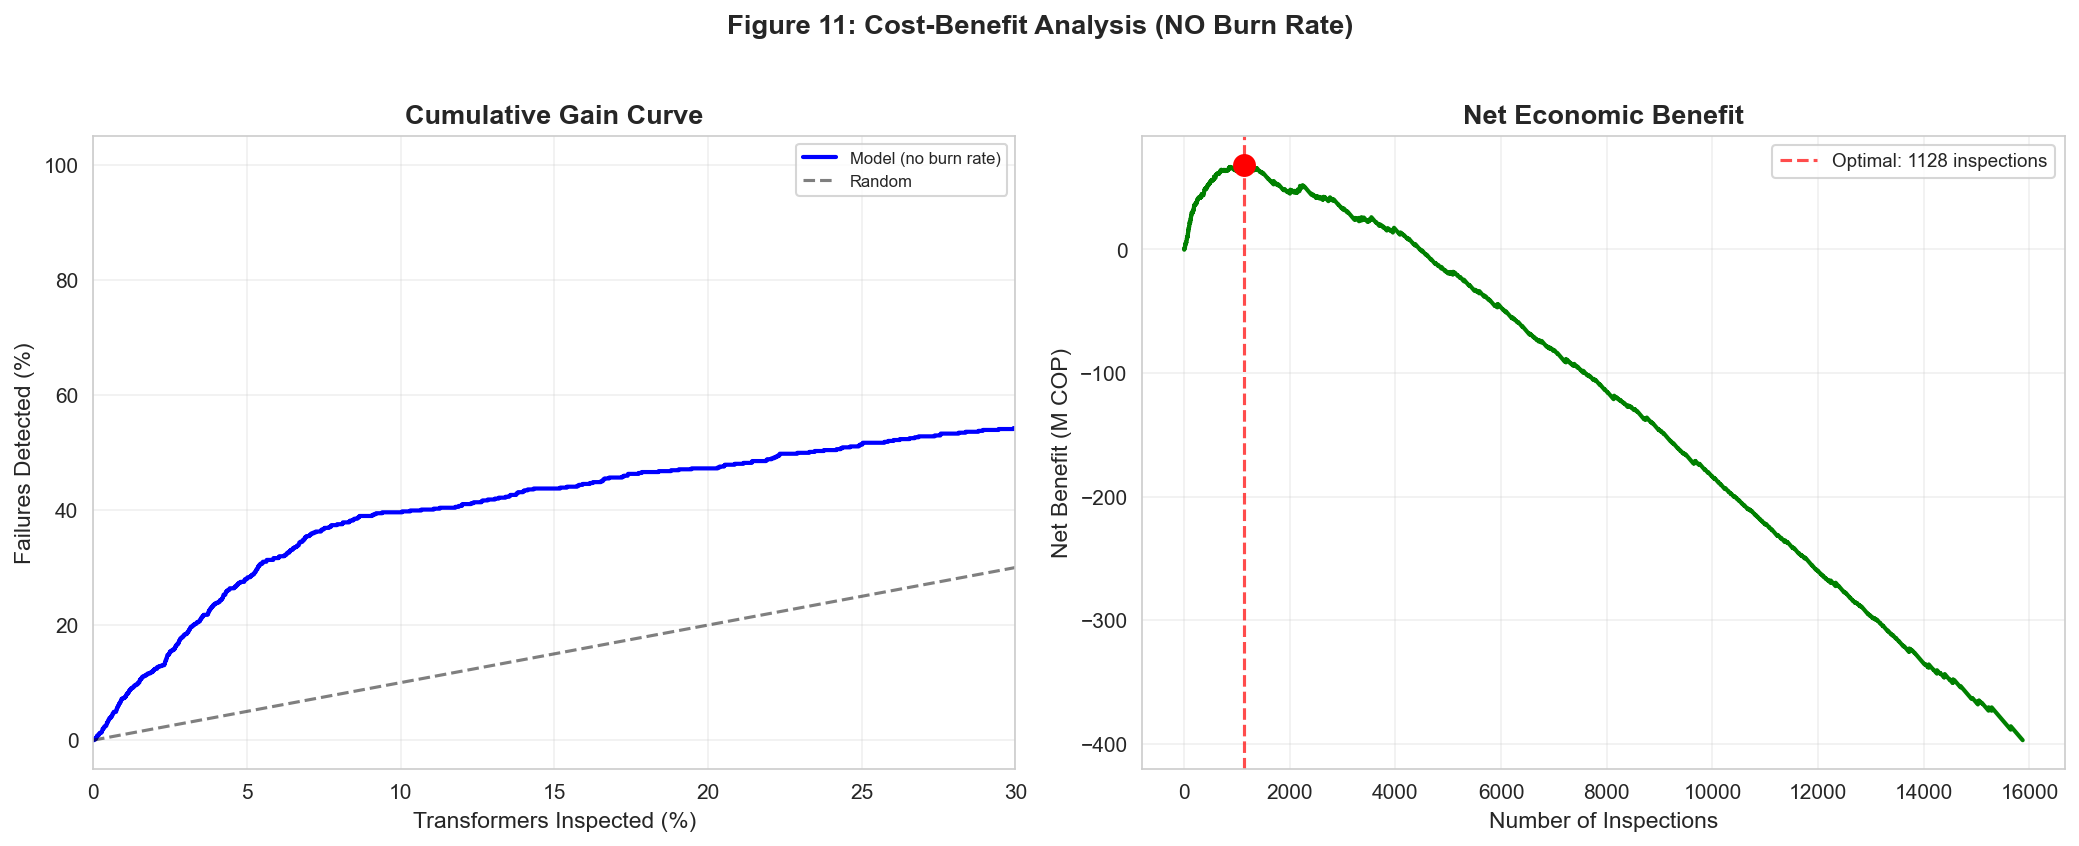


Optimal number of inspections: 1,128
Maximum net benefit: 68,760,000 COP (68.8M COP)
Failures caught at optimal: 226 / 629 (35.9%)


In [27]:
# --- Figure 11: Cost-Benefit Curve ---
n_total = len(risk_df)
sorted_risk = risk_df.sort_values('Expected_Loss_COP', ascending=False)

n_inspections = np.arange(0, n_total + 1)
cumulative_failures_found = np.zeros(n_total + 1)
cumulative_loss_prevented = np.zeros(n_total + 1)
cumulative_inspection_cost = np.zeros(n_total + 1)

for i in range(n_total):
    cumulative_failures_found[i+1] = cumulative_failures_found[i] + sorted_risk.iloc[i]['Actual_Burned']
    cumulative_loss_prevented[i+1] = cumulative_loss_prevented[i] + (
        sorted_risk.iloc[i]['Replacement_Cost_COP'] if sorted_risk.iloc[i]['Actual_Burned'] == 1 else 0
    )
    cumulative_inspection_cost[i+1] = (i + 1) * COST_INSPECTION_COP

total_failures = int(y_2020.sum())
pct_failures_found = cumulative_failures_found / total_failures * 100
net_benefit = cumulative_loss_prevented - cumulative_inspection_cost

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Failures detected vs inspections
ax1 = axes[0]
ax1.plot(n_inspections / n_total * 100, pct_failures_found, 'b-', linewidth=2, label='Model (no burn rate)')
ax1.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Random')
ax1.set_xlabel('Transformers Inspected (%)')
ax1.set_ylabel('Failures Detected (%)')
ax1.set_title('Cumulative Gain Curve', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim([0, 30])  # Focus on first 30%

# Right: Net economic benefit
ax2 = axes[1]
ax2.plot(n_inspections, net_benefit / 1e6, 'g-', linewidth=2)
optimal_idx = np.argmax(net_benefit)
ax2.axvline(x=optimal_idx, color='red', linestyle='--', alpha=0.7,
            label=f'Optimal: {optimal_idx} inspections')
ax2.scatter([optimal_idx], [net_benefit[optimal_idx]/1e6], color='red', s=100, zorder=5)
ax2.set_xlabel('Number of Inspections')
ax2.set_ylabel('Net Benefit (M COP)')
ax2.set_title('Net Economic Benefit', fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Figure 11: Cost-Benefit Analysis (NO Burn Rate)', fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig11_cost_benefit.png", dpi=300, bbox_inches='tight')
plt.show()

# Key stats
print(f"\nOptimal number of inspections: {optimal_idx:,}")
print(f"Maximum net benefit: {net_benefit[optimal_idx]:,.0f} COP ({net_benefit[optimal_idx]/1e6:.1f}M COP)")
print(f"Failures caught at optimal: {int(cumulative_failures_found[optimal_idx])} / {total_failures} ({pct_failures_found[optimal_idx]:.1f}%)")

---
## Section 11: Statistical Robustness (Bootstrap CIs)

1,000-iteration bootstrap confidence intervals for key metrics.

In [28]:
# ============================================================================
# Section 11: Statistical Robustness
# ============================================================================

N_BOOTSTRAP = 1000
rng = np.random.RandomState(SEED)

print(f"Running {N_BOOTSTRAP} bootstrap iterations...\n")

bootstrap_results = []
y_test_arr = np.array(y_2020)

for name, cal_model in calibrated_models.items():
    proba = cal_model.predict_proba(X_test_pp)[:, 1]
    val_proba = cal_model.predict_proba(X_val_pp)[:, 1]
    best_t, _ = optimize_threshold_f2(y_val_2019, val_proba)

    boot_roc = []
    boot_pr = []
    boot_f2 = []

    for b in range(N_BOOTSTRAP):
        idx = rng.choice(len(y_test_arr), len(y_test_arr), replace=True)
        y_b = y_test_arr[idx]
        p_b = proba[idx]

        # Skip if only one class in bootstrap sample
        if y_b.sum() == 0 or y_b.sum() == len(y_b):
            continue

        boot_roc.append(roc_auc_score(y_b, p_b))
        boot_pr.append(average_precision_score(y_b, p_b))
        pred_b = (p_b >= best_t).astype(int)
        boot_f2.append(fbeta_score(y_b, pred_b, beta=2, zero_division=0))

    bootstrap_results.append({
        'Model': name,
        'ROC-AUC': f"{np.mean(boot_roc):.4f} [{np.percentile(boot_roc, 2.5):.4f}, {np.percentile(boot_roc, 97.5):.4f}]",
        'PR-AUC':  f"{np.mean(boot_pr):.4f} [{np.percentile(boot_pr, 2.5):.4f}, {np.percentile(boot_pr, 97.5):.4f}]",
        'F2':      f"{np.mean(boot_f2):.4f} [{np.percentile(boot_f2, 2.5):.4f}, {np.percentile(boot_f2, 97.5):.4f}]",
    })
    print(f"{name}: done")

boot_df = pd.DataFrame(bootstrap_results)
print("\nTABLE 3 (extended): Model Comparison with 95% Bootstrap CIs")
print("=" * 100)
print(boot_df.to_string(index=False))

Running 1000 bootstrap iterations...

SVM (RBF): done
Logistic Regression: done
Random Forest: done
Gradient Boosting: done
XGBoost: done
LightGBM: done

TABLE 3 (extended): Model Comparison with 95% Bootstrap CIs
              Model                 ROC-AUC                  PR-AUC                      F2
          SVM (RBF) 0.7251 [0.7030, 0.7466] 0.1421 [0.1190, 0.1668] 0.2940 [0.2687, 0.3195]
Logistic Regression 0.7269 [0.7049, 0.7479] 0.1544 [0.1306, 0.1791] 0.2819 [0.2588, 0.3045]
      Random Forest 0.7317 [0.7092, 0.7530] 0.1300 [0.1122, 0.1479] 0.3020 [0.2733, 0.3295]
  Gradient Boosting 0.7060 [0.6850, 0.7268] 0.0963 [0.0837, 0.1106] 0.2670 [0.2402, 0.2936]
            XGBoost 0.7313 [0.7097, 0.7522] 0.1349 [0.1145, 0.1580] 0.2900 [0.2615, 0.3182]
           LightGBM 0.7283 [0.7073, 0.7470] 0.1155 [0.0998, 0.1328] 0.2739 [0.2481, 0.3017]


---
## Section 12: Export All Results

Save all figures (300 DPI) and tables (CSV + LaTeX) for the paper.

In [29]:
# ============================================================================
# Section 12: Export All Results
# ============================================================================

# Export tables as CSV
table1.to_csv(OUTPUT_DIR / "table1_dataset_summary.csv", index=False)
table2.to_csv(OUTPUT_DIR / "table2_smote_comparison.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "table3_model_comparison.csv", index=False)
risk_df.head(10).to_csv(OUTPUT_DIR / "table4_top10_risk.csv", index=False)
boot_df.to_csv(OUTPUT_DIR / "table3_bootstrap_CIs.csv", index=False)

# Export tables as LaTeX
with open(OUTPUT_DIR / "table1_dataset_summary.tex", 'w') as f:
    f.write(table1.to_latex(index=False, caption="Dataset Summary", label="tab:dataset"))

with open(OUTPUT_DIR / "table2_smote_comparison.tex", 'w') as f:
    f.write(table2.to_latex(index=False, caption="Resampling Strategy Comparison", label="tab:smote"))

latex_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'F2', 'Precision', 'Recall', 'Lift@5%']
with open(OUTPUT_DIR / "table3_model_comparison.tex", 'w') as f:
    f.write(results_df[latex_cols].to_latex(
        index=False, float_format='%.4f',
        caption="Model Comparison (NO Burn Rate)", label="tab:models_noburn"
    ))

# List all saved outputs
print("Saved outputs:")
for f in sorted(OUTPUT_DIR.glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45s} {size_kb:>8.1f} KB")

print(f"\nAll {len(list(OUTPUT_DIR.glob('fig*')))} figures and {len(list(OUTPUT_DIR.glob('table*')))} tables exported.")
print("Notebook execution complete.")

Saved outputs:
  fig01_class_distribution.png                     131.8 KB
  fig02_correlation_heatmap.png                    375.8 KB
  fig03_eens_distribution.png                      129.1 KB
  fig04_boxplots_top5.png                          133.7 KB
  fig05_calibration_curves.png                     315.8 KB
  fig06_pr_curves.png                              229.8 KB
  fig07_roc_curves.png                             264.6 KB
  fig08_confusion_matrices.png                     368.4 KB
  fig09_shap_beeswarm.png                          326.2 KB
  fig10_shap_dependence_top.png                    118.8 KB
  fig11_cost_benefit.png                           241.5 KB
  table1_dataset_summary.csv                         0.2 KB
  table1_dataset_summary.tex                         0.4 KB
  table2_smote_comparison.csv                        0.2 KB
  table2_smote_comparison.tex                        0.3 KB
  table3_bootstrap_CIs.csv                           0.6 KB
  table3_model_comparison

---
## Verification Checklist

Run this cell to verify key assumptions.

In [30]:
# ============================================================================
# Verification Checks
# ============================================================================
print("VERIFICATION CHECKLIST (NO BURN RATE VERSION)")
print("=" * 60)

# 1. Data integrity
check1 = (len(df_2019) == 15873 and n_pos_19 == 807)
print(f"[{'PASS' if check1 else 'FAIL'}] 2019: 15,873 rows, 807 positives")

check2 = (len(df_2020) == 15873 and n_pos_20 == 629)
print(f"[{'PASS' if check2 else 'FAIL'}] 2020: 15,873 rows, 629 positives")

# 2. No leakage: preprocessor fit only on train
check3 = (len(X_train_2019) + len(X_calib_2019) + len(X_val_2019) == len(X_2019))
print(f"[{'PASS' if check3 else 'FAIL'}] 2019 split sizes add up: {len(X_train_2019)} + {len(X_calib_2019)} + {len(X_val_2019)} = {len(X_2019)}")

# 3. Dummy classifier sanity
dummy_acc = accuracy_score(y_2020, dummy.predict(X_test_pp))
check4 = dummy_acc > 0.95
print(f"[{'PASS' if check4 else 'FAIL'}] Dummy accuracy ({dummy_acc:.2%}) > 95% -- confirms accuracy is misleading")

# 4. Best model PR-AUC > baseline
best_pr = results_df.iloc[0]['PR-AUC']
check5 = best_pr > y_2020.mean()
print(f"[{'PASS' if check5 else 'FAIL'}] Best PR-AUC ({best_pr:.4f}) > baseline ({y_2020.mean():.4f})")

# 5. Burn rate EXCLUDED
check6 = BURN_RATE not in X_2019.columns
print(f"[{'PASS' if check6 else 'FAIL'}] Burning Rate EXCLUDED from features")

# 6. Criticality EXCLUDED
check7 = CRITICALITY not in X_2019.columns
print(f"[{'PASS' if check7 else 'FAIL'}] Criticality EXCLUDED from features")

# 7. SMOTE only on train
check8 = (len(X_train_smote) > len(X_train_pp))
print(f"[{'PASS' if check8 else 'FAIL'}] SMOTE applied ({len(X_train_smote):,} > {len(X_train_pp):,} original train)")

print("\n" + "=" * 60)
all_pass = all([check1, check2, check3, check4, check5, check6, check7, check8])
print(f"Overall: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")

VERIFICATION CHECKLIST (NO BURN RATE VERSION)
[PASS] 2019: 15,873 rows, 807 positives
[PASS] 2020: 15,873 rows, 629 positives
[PASS] 2019 split sizes add up: 9523 + 3175 + 3175 = 15873
[PASS] Dummy accuracy (96.04%) > 95% -- confirms accuracy is misleading
[PASS] Best PR-AUC (0.1531) > baseline (0.0396)
[PASS] Burning Rate EXCLUDED from features
[PASS] Criticality EXCLUDED from features
[PASS] SMOTE applied (18,078 > 9,523 original train)

Overall: ALL CHECKS PASSED
